In [1]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter
import cmath

f1 = 10
f2 = 5
N = 1000
t_n = np.linspace(0, 1, N)
x_n = np.sin(2 * np.pi * f1 * t_n) + 0.5*np.sin(2 * np.pi * f2 * t_n)


In [2]:
#b- calculamos la DFT usando la sumatoria definida en el PDF#

def DFT(x_n):
    N = len(x_n)
    X_k = np.zeros(N, dtype=complex)
    cte = -2j*cmath.pi/N
    for k in range(N):
        suma = 0.0 + 0.0j
        for n in range(N):
            suma += x_n[n] * cmath.exp(cte * k * n)
        X_k[k] = suma
    return X_k


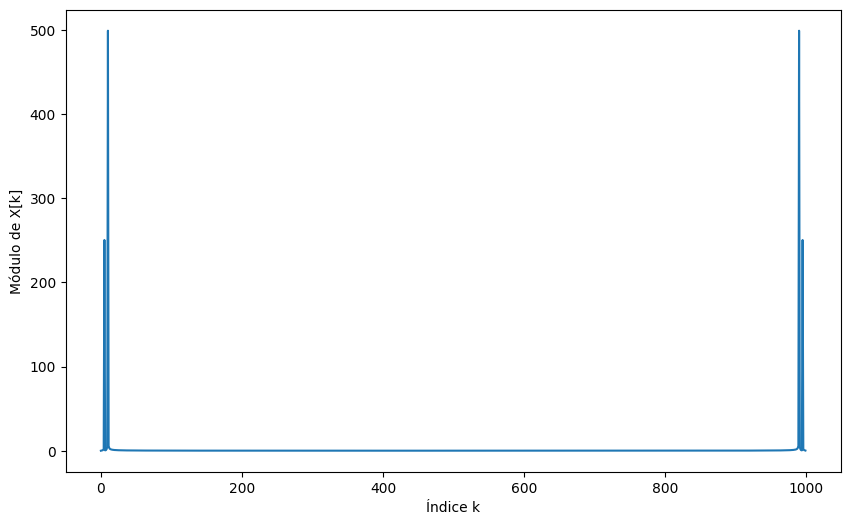

In [3]:
# c- graficamos el modulo de la DFT y graficamos contra el indice k

X_k = DFT(x_n)
plt.figure(figsize=(10, 6))
plt.plot(np.arange(N), np.abs(X_k))
plt.xlabel('Índice k')
plt.ylabel('Módulo de X[k]')
plt.show()



In [10]:
#d- ahora calulamos usando el algoritmo de la FFT de numpy
X_k_fft = np.fft.fft(x_n)



Iniciando benchmarking con 15 iteraciones por tamaño...


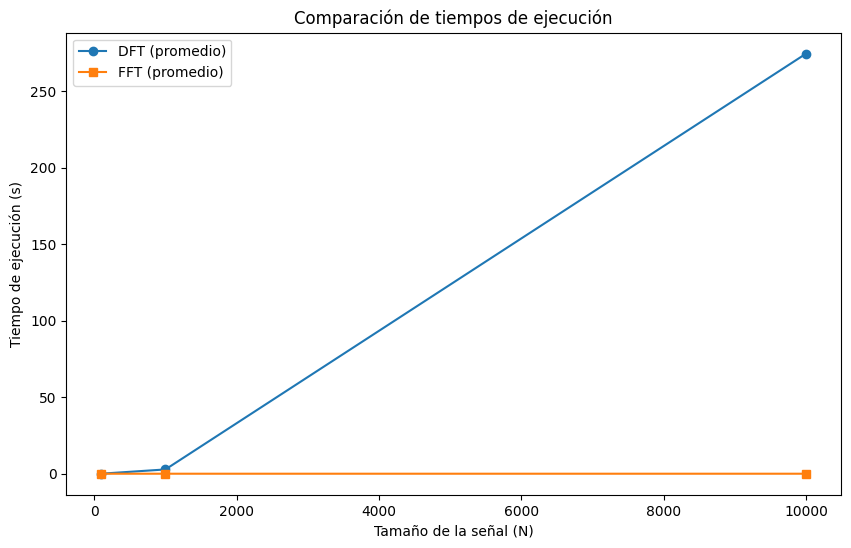

In [16]:
#e- comparamos los resultados de la DFT y la FFT en terminos de tiempo de ejecucion
# usando distintos tamaños de N

N_values = [100,1000,10000]
num_repeticiones = 15
tiempos_dft_prom = []
tiempos_fft_prom = []
print(f"Iniciando benchmarking con {num_repeticiones} iteraciones por tamaño...")

for N in N_values:
    suma_dft = 0
    suma_fft = 0

    for i in range(num_repeticiones):
        t_n = np.linspace(0, 1, N)
        x_n = np.sin(2 * np.pi * f1 * t_n) + 0.5*np.sin(2 * np.pi * f2 * t_n)

        start_time = perf_counter()
        DFT(x_n)
        end_time = perf_counter()
        suma_dft += (end_time - start_time)

        start_time = perf_counter()
        np.fft.fft(x_n)
        end_time = perf_counter()
        suma_fft += (end_time - start_time)

    tiempos_dft_prom.append(suma_dft / num_repeticiones)
    tiempos_fft_prom.append(suma_fft / num_repeticiones)
plt.figure(figsize=(10, 6))
plt.plot(N_values, tiempos_dft_prom, label='DFT (promedio)', marker='o')
plt.plot(N_values, tiempos_fft_prom, label='FFT (promedio)', marker='s')
plt.xlabel('Tamaño de la señal (N)')
plt.ylabel('Tiempo de ejecución (s)')
plt.title('Comparación de tiempos de ejecución')
plt.legend()
plt.show()

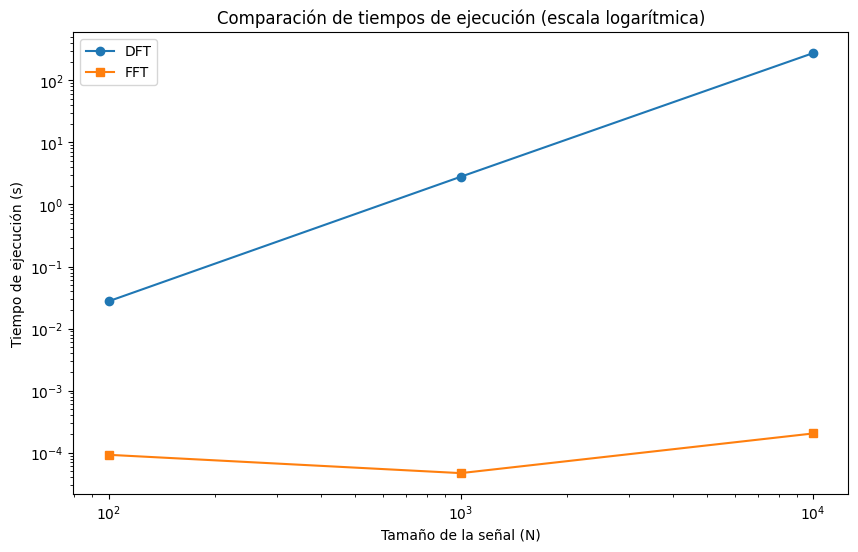

Exponente DFT: 2.00
Exponente FFT: 0.17


In [17]:
#g- repetimos el grafico pero para una escala logaritmica en ambos ejes
# y calcular el exponente de cada algoritmo usando una regresion lineal en la escala logaritmica
plt.figure(figsize=(10, 6))
plt.loglog(N_values, tiempos_dft_prom, label='DFT', marker='o')
plt.loglog(N_values, tiempos_fft_prom, label='FFT', marker='s')
plt.xlabel('Tamaño de la señal (N)')
plt.ylabel('Tiempo de ejecución (s)')
plt.title('Comparación de tiempos de ejecución (escala logarítmica)')
plt.legend()    
plt.show()

expontente_dft = np.polyfit(np.log(N_values), np.log(tiempos_dft_prom), 1)[0]
expontente_fft = np.polyfit(np.log(N_values), np.log(tiempos_fft_prom), 1)[0]
print(f'Exponente DFT: {expontente_dft:.2f}')
print(f'Exponente FFT: {expontente_fft:.2f}')

In [18]:
#h-Calculamos el ratio de los tiempos de ejecucion de ambos algoritmos para encontar en que N aprox
# la fft se vuelve 100 mas rapida que la DFT

ratios = np.array(tiempos_dft_prom) / np.array(tiempos_fft_prom)
umbral = 100
for N, ratio in zip(N_values, ratios):
    if ratio >= umbral:
        print(f'La FFT es aproximadamente {umbral} veces más rápida que la DFT para N={N}')
        break
    


La FFT es aproximadamente 100 veces más rápida que la DFT para N=100
